
# การดำเนินการอนุมานทั้งมวล

ensemble inference workflow อย่างง่าย

ตัวอย่างนี้จะสาธิตวิธีการรัน inference workflow อย่างง่ายเพื่อสร้าง
ensemble forecast โดยใช้โมเดล Earth-2 Inference ในตัวรุ่นใดรุ่นหนึ่ง
Studio

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีสร้างอินสแตนซ์ของโมเดลพยากรณ์ที่มีมาให้ในระบบ
- วิธีสร้างแหล่งข้อมูลและออบเจ็กต์ IO
- เลือกวิธีการก่อกวน
- ใช้งาน workflow ในตัวแบบเรียบง่ายสำหรับการประกอบ
- วิธีทำ post-processing กับผลลัพธ์


In [ ]:
# /// script
# dependencies = [
#   "torch==2.9.1", # Match lock file to avoid torch-harmonics issue
#   "earth2studio[fcn,perturbation] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "scipy>=1.15.2",
#   "cartopy",
# ]
#
# [เครื่องมือ.ยูวี]
# no-build-isolation-package = ["torch-harmonics"]
# ///

## การเตรียมองค์ประกอบ
workflow ทุกตัวภายใน Earth2Studio จำเป็นต้องได้รับคอมโพเนนต์ที่สร้างไว้ล่วงหน้า
แล้วส่งเข้าไปให้ใช้งาน ในตัวอย่างนี้ เราจะใช้ ensemble workflow ในตัว
:py:meth:`earth2studio.run.ensemble`.



.. literalinclude:: ../../earth2studio/run.py
   :language: python
   :start-after: # sphinx - ensemble start
   :end-before: # sphinx - ensemble end



เราจำเป็นต้องมีองค์ประกอบต่อไปนี้:

- Prognostic Model: ใช้ FourCastNet รุ่น :py:class:`earth2studio.models.px.FCN` ในตัว
- วิธีการก่อกวน: ใช้วิธีเกาส์เซียนทรงกลม :py:class:`earth2studio.perturbation.SphericalGaussian`
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกเอาต์พุตลงในร้านค้า Zarr :py:class:`earth2studio.io.ZarrBackend`



In [1]:
import io
import os
import warnings
from contextlib import redirect_stdout

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

# ซ่อน warning จาก dependency ที่ยังไม่กระทบการทำงานจริง
warnings.filterwarnings("ignore", message=r".*IProgress not found.*")

import numpy as np

# warp-lang บางเวอร์ชันพ่นข้อความ deprecation ลง stdout ตรง ๆ ระหว่าง import
_buf = io.StringIO()
with redirect_stdout(_buf):
    from earth2studio.data import GFS
    from earth2studio.io import ZarrBackend
    from earth2studio.models.px import FCN
    from earth2studio.perturbation import SphericalGaussian
    from earth2studio.run import ensemble

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = FCN.load_default_package()
model = FCN.load_model(package)

# ยกตัวอย่างวิธีการก่อกวน
sg = SphericalGaussian(noise_amplitude=0.15)

# สร้างแหล่งข้อมูล
data = GFS()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
chunks = {"ensemble": 1, "time": 1, "lead_time": 1}
io = ZarrBackend(
    file_name="outputs/03_ensemble_sg.zarr",
    chunks=chunks,
    backend_kwargs={"overwrite": True},
)

## การรัน Workflow
เมื่อคอมโพเนนต์ทั้งหมดเริ่มต้นแล้ว การรัน workflow จะเป็นโค้ด Python บรรทัดเดียว
เวิร์กโฟลว์จะส่งคืนอ็อบเจ็กต์ IO ที่ระบุกลับไปยังผู้ใช้ ซึ่งสามารถนำมาใช้ได้
จากนั้นจึงโพสต์กระบวนการ บางตัวมี API เพิ่มเติมซึ่งมีประโยชน์สำหรับ post-processing หรือ
บันทึกเป็นไฟล์ ตรวจสอบเอกสาร API สำหรับข้อมูลเพิ่มเติม

สำหรับการพยากรณ์ เราจะคาดการณ์ 10 ขั้นตอน (สำหรับ FCN คือ 60 ชั่วโมง) โดยมี 8 ensemble
สมาชิกที่จะวิ่งใน 2 batches กับ batch ขนาด 4



In [2]:
nsteps = 10
nensemble = 8
batch_size = 2
io = ensemble(
    ["2026-04-23"],
    nsteps,
    nensemble,
    model,
    data,
    io,
    sg,
    batch_size=batch_size,
    output_coords={"variable": np.array(["t2m", "tcwv"])},
)

2026-04-24 11:50:21.974 | INFO     | earth2studio.run:ensemble:328 - Running ensemble inference!
2026-04-24 11:50:21.975 | INFO     | earth2studio.run:ensemble:336 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-24 11:50:22.260 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 418997774-949153
2026-04-24 11:50:22.281 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 264489755-930883
2026-04-24 11:50:22.293 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 210319858-594916
2026-04-24 11:50:22.305 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 342505783-940244
2026-04-24 11:50:22.317 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 413943594-876479
2026-04-24 11:50:22.330 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 78.02it/s]


2026-04-24 11:50:22.467 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 399205784-952931
2026-04-24 11:50:22.479 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 259696650-826593
2026-04-24 11:50:22.491 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 403353752-999414
2026-04-24 11:50:22.503 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 337545291-872472
2026-04-24 11:50:22.516 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 425763906-1197334
2026-04-24 11:50:22.529 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS






Total Ensemble Batches: 100%|██████████| 4/4 [00:36<00:00,  9.05s/it]

2026-04-24 11:50:58.827 | SUCCESS  | earth2studio.run:ensemble:439 - 
Inference complete


## การทำ Post-Processing
ขั้นตอนสุดท้ายคือการนำผลลัพธ์มาทำ post-process ต่อ Cartopy เป็นไลบรารีที่เหมาะมากสำหรับการพล็อตฟิลด์ข้อมูลบน projection ของทรงกลม

สังเกตว่า Zarr IO function มี API เพิ่มเติมสำหรับใช้เข้าถึงและจัดการข้อมูลที่จัดเก็บไว้



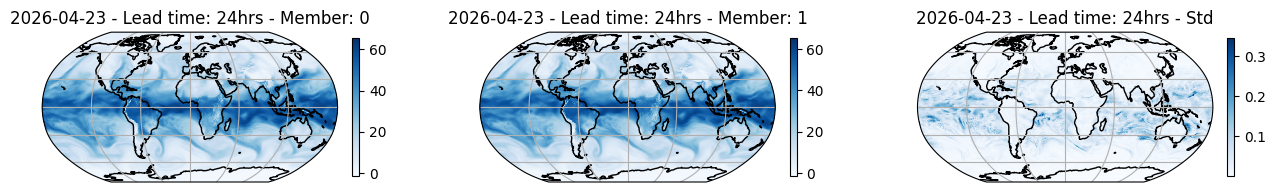

In [3]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

forecast = "2026-04-23"


def plot_(axi, data, title, cmap):
    """Convenience function for plotting pcolormesh."""
    # พล็อตฟิลด์โดยใช้ pcolormesh
    im = axi.pcolormesh(
        io["lon"][:],
        io["lat"][:],
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
    )
    plt.colorbar(im, ax=axi, shrink=0.6, pad=0.04)
    # ตั้งชื่อเรื่อง
    axi.set_title(title)
    # เพิ่มแนวชายฝั่งและเส้นกริด
    axi.coastlines()
    axi.gridlines()


for variable, cmap in zip(["tcwv"], ["Blues"]):
    step = 4  # lead time = 24 ชม

    plt.close("all")
    # สร้างโรบินสัน projection
    projection = ccrs.Robinson()

    # สร้างรูปและแกนด้วย projection ที่ระบุ
    fig, (ax1, ax2, ax3) = plt.subplots(
        nrows=1, ncols=3, subplot_kw={"projection": projection}, figsize=(16, 3)
    )

    plot_(
        ax1,
        io[variable][0, 0, step],
        f"{forecast} - Lead time: {6*step}hrs - Member: {0}",
        cmap,
    )
    plot_(
        ax2,
        io[variable][1, 0, step],
        f"{forecast} - Lead time: {6*step}hrs - Member: {1}",
        cmap,
    )
    plot_(
        ax3,
        np.std(io[variable][:, 0, step], axis=0),
        f"{forecast} - Lead time: {6*step}hrs - Std",
        cmap,
    )

    plt.savefig(f"outputs/03_{forecast}_{variable}_{step}_ensemble.jpg")